Ejercicio 12: Multimodal Embeddings
Objetivo de la práctica
El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

Pasos:
Obtener embeddings de imágenes y textos con CLIP.
Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

In [ ]:
!pip install torch torchvision ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
!pip install scikit-learn matplotlib pillow


  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-cgznrv51
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-cgznrv51
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import clip
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import urllib.request


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
print("Dispositivo:", device)


Dispositivo: cuda


In [ ]:
image_urls = {
    # Perros
    "perro1.jpg": "https://images.unsplash.com/photo-1517849845537-4d257902454a",
    "perro2.jpg": "https://images.unsplash.com/photo-1558788353-f76d92427f16",

    # Gatos
    "gato1.jpg": "https://images.unsplash.com/photo-1518791841217-8f162f1e1131",
    "gato2.jpg": "https://images.unsplash.com/photo-1595433707802-6b2626ef1c91",

    # Autos
    "auto1.jpg": "https://images.unsplash.com/photo-1503376780353-7e6692767b70",
    "auto2.jpg": "https://images.unsplash.com/photo-1549924231-f129b911e442",

    # Aviones
    "avion1.jpg": "https://images.unsplash.com/photo-1529070538774-1843cb3265df",
    "avion2.jpg": "https://images.unsplash.com/photo-1436491865332-7a61a109cc05",

    # Personas
    "persona1.jpg": "https://images.unsplash.com/photo-1500648767791-00dcc994a43e",
    "persona2.jpg": "https://images.unsplash.com/photo-1529626455594-4ff0802cfb7e",

    # Comida
    "comida1.jpg": "https://images.unsplash.com/photo-1546069901-ba9599a7e63c",
    "comida2.jpg": "https://images.unsplash.com/photo-1504674900247-0877df9cc836",
}

image_paths = []

for name, url in image_urls.items():
    urllib.request.urlretrieve(url + "?w=640", name)
    image_paths.append(name)

len(image_paths)


12

In [ ]:
images = [
    preprocess(Image.open(p).convert("RGB")).unsqueeze(0).to(device)
    for p in image_paths
]

with torch.no_grad():
    image_embeddings = torch.cat([model.encode_image(img) for img in images])

image_embeddings /= image_embeddings.norm(dim=-1, keepdim=True)
print("Embeddings imagen:", image_embeddings.shape)


Embeddings imagen: torch.Size([12, 512])


In [ ]:
texts = [
    "un perro",
    "un gato",
    "un automóvil",
    "un avión",
    "una persona",
    "comida"
]

text_tokens = clip.tokenize(texts).to(device)

with torch.no_grad():
    text_embeddings = model.encode_text(text_tokens)

text_embeddings /= text_embeddings.norm(dim=-1, keepdim=True)
print("Embeddings texto:", text_embeddings.shape)


Embeddings texto: torch.Size([6, 512])


In [ ]:
print("Dimensión imagen:", image_embeddings.shape[1])
print("Dimensión texto:", text_embeddings.shape[1])


Dimensión imagen: 512
Dimensión texto: 512


In [ ]:
similarity = cosine_similarity(
    text_embeddings.cpu().numpy(),
    image_embeddings.cpu().numpy()
)

similarity


array([[0.27275227, 0.24104618, 0.19476483, 0.20193936, 0.17916886,
        0.15994033, 0.16470586, 0.17434486, 0.20665551, 0.18478396,
        0.16241114, 0.15828483],
       [0.22751386, 0.17480052, 0.25009686, 0.25147116, 0.19798185,
        0.16506185, 0.16697505, 0.16711094, 0.21121224, 0.2058138 ,
        0.15519554, 0.14825958],
       [0.21412745, 0.17195776, 0.17425417, 0.17488105, 0.22845151,
        0.1683131 , 0.18033121, 0.16504773, 0.21151919, 0.18421242,
        0.16256471, 0.14054433],
       [0.19941456, 0.18112555, 0.17528744, 0.18409404, 0.18755708,
        0.17366815, 0.18806964, 0.25143231, 0.20688494, 0.21032818,
        0.17770663, 0.16132425],
       [0.24347589, 0.2135141 , 0.20696523, 0.21187637, 0.19779975,
        0.18123943, 0.19869458, 0.18084036, 0.24411072, 0.23957075,
        0.16576032, 0.17029786],
       [0.21404511, 0.18569073, 0.18281302, 0.20511326, 0.17922359,
        0.17330503, 0.1631011 , 0.17079113, 0.19807729, 0.18902179,
        0.22145947,

In [ ]:
all_embeddings = torch.cat([image_embeddings, text_embeddings]).cpu().numpy()

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)

img_2d = embeddings_2d[:len(image_embeddings)]
txt_2d = embeddings_2d[len(image_embeddings):]


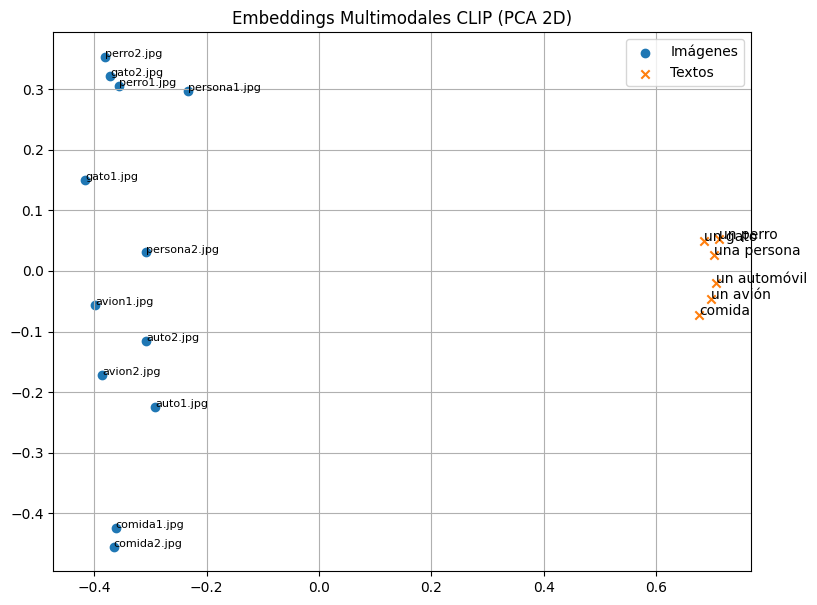

In [ ]:
plt.figure(figsize=(9,7))

plt.scatter(img_2d[:,0], img_2d[:,1], marker='o', label='Imágenes')
for i, name in enumerate(image_paths):
    plt.text(img_2d[i,0], img_2d[i,1], name, fontsize=8)

plt.scatter(txt_2d[:,0], txt_2d[:,1], marker='x', label='Textos')
for i, txt in enumerate(texts):
    plt.text(txt_2d[i,0], txt_2d[i,1], txt, fontsize=10)

plt.title("Embeddings Multimodales CLIP (PCA 2D)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def buscar_imagen(texto):
    token = clip.tokenize([texto]).to(device)

    with torch.no_grad():
        emb = model.encode_text(token)
        emb /= emb.norm(dim=-1, keepdim=True)

    scores = cosine_similarity(
        emb.cpu().numpy(),
        image_embeddings.cpu().numpy()
    )[0]

    idx = np.argmax(scores)

    print("Texto:", texto)
    print("Imagen más similar:", image_paths[idx])
    plt.imshow(Image.open(image_paths[idx]))
    plt.axis("off")
    plt.show()


Texto: un gato jugando
Imagen más similar: gato1.jpg


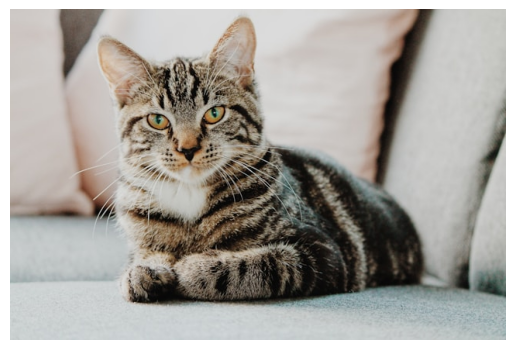

In [ ]:
buscar_imagen("un gato jugando")


In [ ]:
def buscar_texto(nombre_imagen):
    img = preprocess(Image.open(nombre_imagen).convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model.encode_image(img)
        emb /= emb.norm(dim=-1, keepdim=True)

    scores = cosine_similarity(
        emb.cpu().numpy(),
        text_embeddings.cpu().numpy()
    )[0]

    idx = np.argmax(scores)

    print("Imagen:", nombre_imagen)
    print("Texto más cercano:", texts[idx])
    plt.imshow(Image.open(nombre_imagen))
    plt.axis("off")
    plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving persona.jpg to persona.jpg


In [ ]:
labels = [
    "un perro",
    "un gato",
    "una persona",
    "un automóvil",
    "un avión",
    "comida",
    "una mascota",
    "un animal",
    "un objeto",
    "un paisaje"
]

label_tokens = clip.tokenize(labels).to(device)

with torch.no_grad():
    label_embeddings = model.encode_text(label_tokens)

label_embeddings /= label_embeddings.norm(dim=-1, keepdim=True)


In [ ]:
def clasificar_imagen(nombre_imagen):
    img = preprocess(
        Image.open(nombre_imagen).convert("RGB")
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model.encode_image(img)
        emb /= emb.norm(dim=-1, keepdim=True)

    scores = cosine_similarity(
        emb.cpu().numpy(),
        label_embeddings.cpu().numpy()
    )[0]

    idx = np.argmax(scores)

    print("Imagen subida:", nombre_imagen)
    print("Predicción CLIP:", labels[idx])
    print("\nSimilitudes:")

    for i, label in enumerate(labels):
        print(f"{label:15s} → {scores[i]:.3f}")

    plt.imshow(Image.open(nombre_imagen))
    plt.axis("off")
    plt.show()


Imagen subida: persona.jpg
Predicción CLIP: una persona

Similitudes:
un perro        → 0.183
un gato         → 0.160
una persona     → 0.202
un automóvil    → 0.186
un avión        → 0.176
comida          → 0.163
una mascota     → 0.165
un animal       → 0.184
un objeto       → 0.197
un paisaje      → 0.193


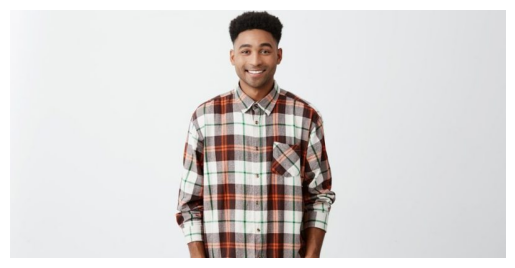

In [ ]:
clasificar_imagen("persona.jpg")
